## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [1]:
%pip install folium
%pip install kneed
%pip install yellowbrick


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\mythi\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\mythi\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Users\mythi\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
# TODO, Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
# Xử lý dữ liệu khuyết cho Income bằng mean
customer_data['Income'] = customer_data['Income'].fillna(
    customer_data['Income'].mean()
)

print("Số lượng Income bị thiếu sau khi xử lý:",
      customer_data['Income'].isna().sum())

Số lượng Income bị thiếu sau khi xử lý: 0


#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [8]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia

customer_data['Dt_Customer'] = pd.to_datetime(
    customer_data['Dt_Customer'],
    format='%d-%m-%Y'
)

now = datetime.datetime.now()

customer_data['Enroll_days'] = (
    now - customer_data['Dt_Customer']
).dt.days

customer_data[['Dt_Customer', 'Enroll_days']].head()

,Dt_Customer,Enroll_days
ID,,
5524,2012-09-04,5145
2174,2014-03-08,4595
4141,2013-08-21,4794
6182,2014-02-10,4621
5324,2014-01-19,4643


- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [9]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)

customer_data['Fam_Size'] = (
    customer_data['Marital_Status']
    + customer_data['Kidhome']
    + customer_data['Teenhome']
)

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [10]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = (
    customer_data['AcceptedCmp1']
    + customer_data['AcceptedCmp2']
    + customer_data['AcceptedCmp3']
    + customer_data['AcceptedCmp4']
    + customer_data['AcceptedCmp5']
)

In [11]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = (
    customer_data['MntWines']
    + customer_data['MntFruits']
    + customer_data['MntMeatProducts']
    + customer_data['MntFishProducts']
    + customer_data['MntSweetProducts']
    + customer_data['MntGoldProds']
)

#### A4. Phân tích EDA

In [12]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4835.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4482.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4662.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4837.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5011.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5181.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

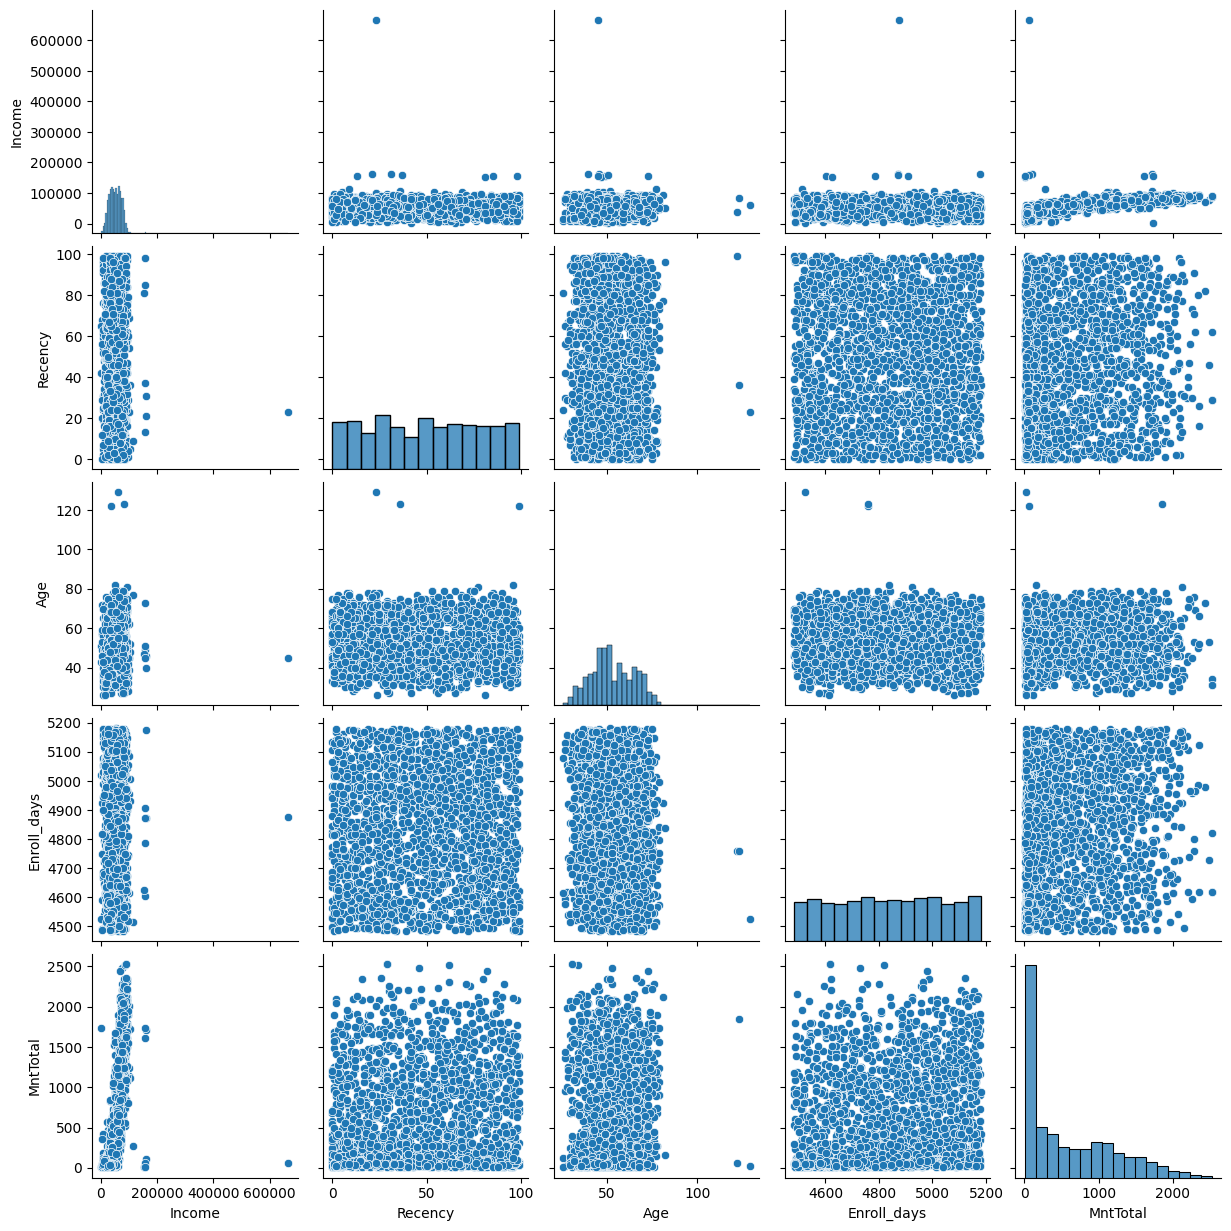

In [14]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
sns.pairplot(
    customer_data[plot_cols],
    diag_kind='hist'
)

plt.show()

In [15]:
# TODO - xử lý nhiễu (nếu có)
for col in plot_cols:
    Q1 = customer_data[col].quantile(0.25)
    Q3 = customer_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    customer_data = customer_data[
        (customer_data[col] >= lower_bound) &
        (customer_data[col] <= upper_bound)
    ]

print("Kích thước dữ liệu sau khi xử lý nhiễu:", customer_data.shape)

Kích thước dữ liệu sau khi xử lý nhiễu: (2226, 33)


In [16]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [17]:
# TODO
# Kiểm tra các đặc trưng kiểu loại
categorical_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

print("Các đặc trưng kiểu loại:", categorical_cols)

Các đặc trưng kiểu loại: []


In [18]:
# Mã hoá các đặc trưng kiểu loại
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
ID,,,,,,,,,,,
5524,58138.0,58,3,8,10,4,7,65,5145,1,1617
2174,46344.0,38,2,1,1,2,5,68,4595,3,27
4141,71613.0,26,1,8,2,10,4,57,4794,2,776
6182,26646.0,26,2,2,0,4,6,38,4621,3,53
5324,58293.0,94,5,5,3,6,5,41,4643,3,422


**Chuẩn hoá các thuộc tính kiểu số**

In [19]:
# TODO
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

df = pd.DataFrame(
    df_scaled,
    columns=df.columns,
    index=df.index
)

df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
ID,,,,,,,,,,,
5524,0.319038,0.306764,0.357875,1.405082,2.639583,-0.557672,0.688640,1.014839,1.528030,-1.762774,1.698128
2174,-0.254513,-0.384037,-0.169695,-1.116686,-0.584500,-1.174965,-0.140410,1.271537,-1.191595,0.443543,-0.964498
4141,0.974338,-0.798517,-0.697265,1.405082,-0.226268,1.294209,-0.554934,0.330310,-0.207585,-0.659615,0.289783
6182,-1.212442,-0.798517,-0.169695,-0.756433,-0.942731,-0.557672,0.274115,-1.295446,-1.063030,0.443543,-0.920958
5324,0.326576,1.550205,1.413016,0.324324,0.131963,0.059622,-0.140410,-1.038748,-0.954245,0.443543,-0.303028


In [20]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03,2226.000000,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03,2.226000e+03
mean,2.872814e-17,1.037405e-17,-2.553613e-17,1.436407e-16,0.000000,1.356607e-16,-2.872814e-17,2.234411e-17,-2.072416e-15,2.266331e-16,-7.341637e-17
std,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00,1.000225,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00,1.000225e+00
min,-2.424127e+00,-1.696558e+00,-1.224835e+00,-1.476938e+00,-0.942731,-1.792259e+00,-2.213034e+00,-2.322240e+00,-1.750354e+00,-1.762774e+00,-1.001339e+00
25%,-7.869717e-01,-8.675972e-01,-6.972646e-01,-7.564331e-01,-0.942731,-8.663184e-01,-9.694592e-01,-6.964836e-01,-8.553500e-01,-6.596154e-01,-8.941644e-01
50%,-2.168069e-03,1.317362e-02,-1.696946e-01,-3.592814e-02,-0.226268,-2.490250e-01,2.741152e-01,-9.752077e-02,9.985063e-03,4.435430e-01,-3.465678e-01
75%,8.009086e-01,8.594044e-01,3.578755e-01,6.845768e-01,0.490195,6.769153e-01,6.886401e-01,8.437065e-01,8.654306e-01,4.435430e-01,7.343913e-01
max,3.022716e+00,1.722905e+00,6.688716e+00,8.249879e+00,9.087750,2.220149e+00,6.077463e+00,2.469463e+00,1.706042e+00,2.649860e+00,3.153362e+00


#### A6. Phân cụm KMeans

In [21]:
from sklearn.cluster import KMeans


Phương pháp Elbow: ước lượng số cụm

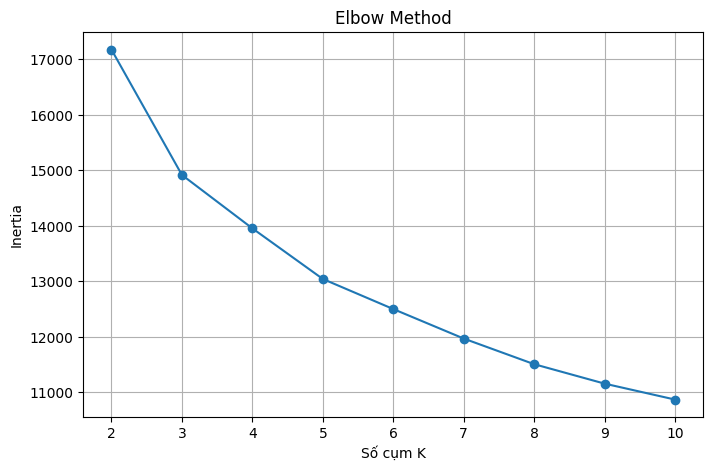

In [22]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
# Vẽ biểu đồ Elbow
inertias = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=99
    )
    model.fit(df)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Số cụm K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [23]:
from yellowbrick.cluster import KElbowVisualizer

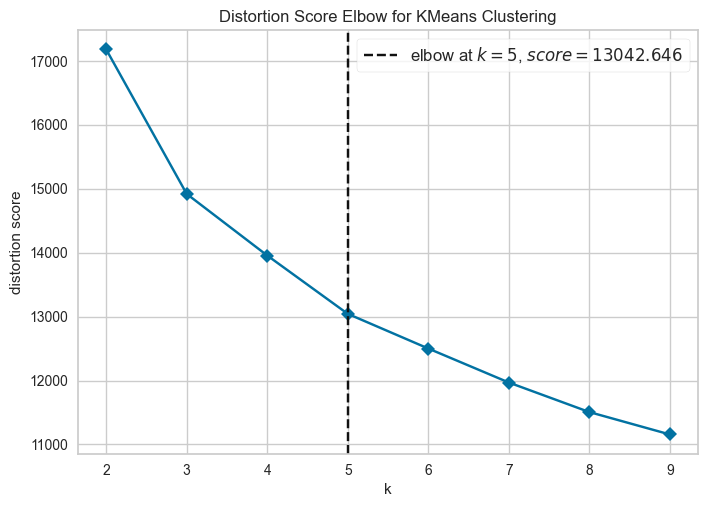

K tối ưu: 5


In [24]:
# TODO
model = KMeans(
    n_init=20,
    random_state=99
)

visualizer = KElbowVisualizer(
    model,
    k=(2, 10),
    metric='distortion',
    timings=False
)

visualizer.fit(df)
visualizer.show()

K = visualizer.elbow_value_

print("K tối ưu:", K)

**Phân cụm từ kết quả của phương pháp Elbow**

In [25]:
# TODO
kmean = KMeans(
    n_clusters=K,
    n_init=20,
    random_state=99
)

kmean.fit(df)

print("Tâm cụm:")
print(kmean.cluster_centers_)

print("\nNhãn các cụm:")
print(kmean.labels_)

Tâm cụm:
[[-1.09938693e+00 -1.38211292e-01 -2.65702828e-01 -7.24627016e-01
  -7.78783970e-01 -8.65762311e-01  7.67810577e-01 -7.00337922e-01
   2.36268517e-01 -5.33751738e-02 -8.59543773e-01]
 [ 1.24391796e+00  9.98975149e-02 -6.83561509e-01  1.73829248e-01
   1.26946432e+00  7.89818511e-01 -1.27810974e+00  2.34200816e-02
  -1.53235222e-01 -1.00345692e+00  1.32447299e+00]
 [-4.21528361e-01  1.97410723e-01 -2.03208257e-01 -6.81872639e-01
  -6.63046528e-01 -6.36098323e-01 -4.35738594e-02  3.80457169e-01
  -7.55623701e-01  6.42473203e-01 -7.88317538e-01]
 [-1.35187489e-01  3.95319183e-03  2.08812635e+00  5.83828228e-01
  -1.26085019e-01  1.64635565e-02  7.87001893e-01  1.27996706e-01
   5.93028148e-01  8.73587791e-01 -1.58259572e-01]
 [ 5.63051001e-01 -1.37556228e-01  1.43584118e-01  1.06562735e+00
   4.10423420e-01  8.70376315e-01 -2.40357666e-04  3.34014738e-01
   3.47330657e-01 -5.45841706e-02  5.92141214e-01]]

Nhãn các cụm:
[4 2 4 ... 1 4 3]


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [26]:
from sklearn.decomposition import PCA

In [27]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO
pca_2d = PCA(
    n_components=2,
    random_state=99
)

scores = pca_2d.fit_transform(df)

print("Shape:", scores.shape)

print("Tỷ lệ phương sai:",
      pca_2d.explained_variance_ratio_)

print("Tổng thông tin giữ lại:",
      pca_2d.explained_variance_ratio_.sum())

Shape: (2226, 2)
Tỷ lệ phương sai: [0.37412712 0.16101261]
Tổng thông tin giữ lại: 0.5351397319020772


**Trực quan hoá kết quả phân cụm**

In [28]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [29]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5145,1,0,1617,4
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4595,3,0,27,2
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4794,2,0,776,4
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4621,3,0,53,0
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4643,3,0,422,3


In [30]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

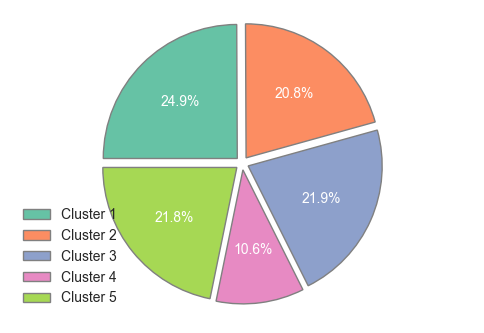

In [31]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

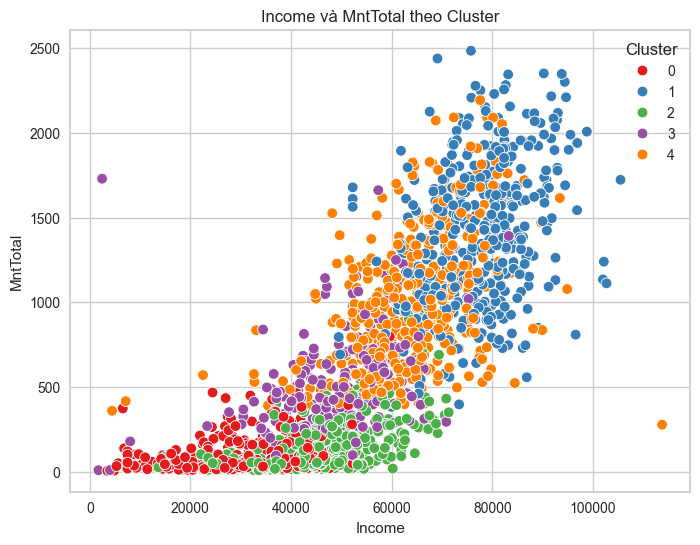

In [32]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=kmean_df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Income và MntTotal theo Cluster')
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.grid(True)
plt.show()

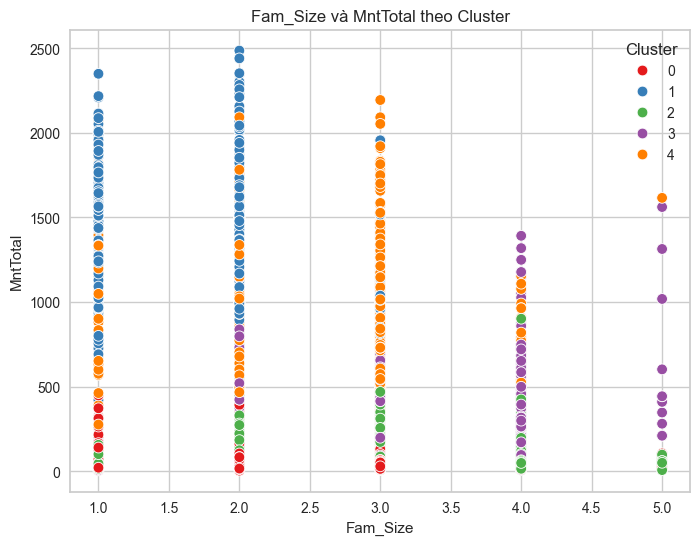

In [33]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=kmean_df,
    x='Fam_Size',
    y='MntTotal',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Fam_Size và MntTotal theo Cluster')
plt.xlabel('Fam_Size')
plt.ylabel('MntTotal')
plt.grid(True)
plt.show()

**Phân tích danh mục mua hàng**

In [34]:
# TODO
mnt_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

category_mean = (
    kmean_df
    .groupby('Cluster')[mnt_cols]
    .mean()
)

print(category_mean.round(2))

         MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                          
0           29.09       5.99            22.38             9.05   
1          617.85      64.61           475.55            95.29   
2           69.83       5.53            28.05             7.49   
3          303.76      13.02           104.21            20.86   
4          554.44      39.95           196.63            53.59   

         MntSweetProducts  MntGoldProds  
Cluster                                  
0                    5.88         17.29  
1                   65.50         75.08  
2                    5.54         15.77  
3                   15.54         51.06  
4                   41.68         70.26  


#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [35]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(df)

# Tính phương sai tích lũy
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print("Phương sai tích lũy:")
print(cumulative_variance)

# Chọn số component giữ ít nhất 70% thông tin
n_components = np.argmax(
    cumulative_variance >= 0.70
) + 1

print("Số component:", n_components)
print("Thông tin giữ lại:", cumulative_variance[n_components - 1])

Phương sai tích lũy:
[0.37412712 0.53513973 0.63917842 0.73062632 0.80495813 0.85985716
 0.90427059 0.9432684  0.96973964 0.98917231 1.        ]
Số component: 4
Thông tin giữ lại: 0.7306263242992767


In [36]:
pca_model = PCA(
    n_components=n_components,
    random_state=99
)

pca_transformed = pca_model.fit_transform(df)

print("Shape:", pca_transformed.shape)
print(
    "Tỷ lệ phương sai:",
    pca_model.explained_variance_ratio_
)
print(
    "Tổng thông tin giữ lại:",
    pca_model.explained_variance_ratio_.sum()
)

Shape: (2226, 4)
Tỷ lệ phương sai: [0.37412712 0.16101261 0.10403869 0.0914479 ]
Tổng thông tin giữ lại: 0.7306263242992767


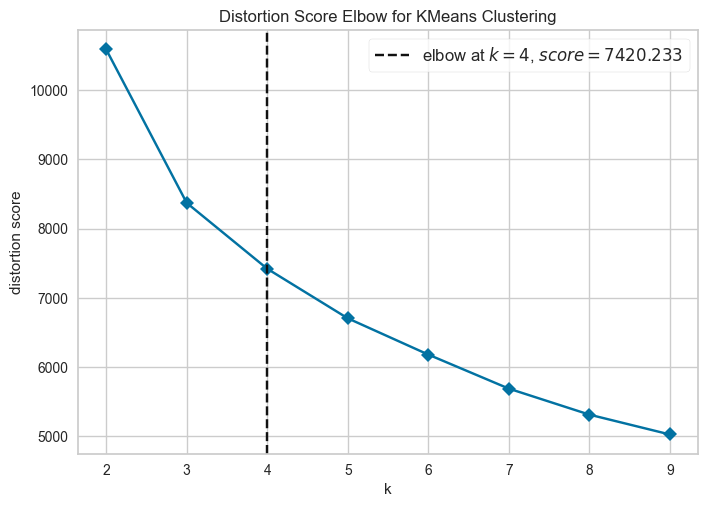

K tối ưu sau PCA: 4


In [37]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(
    n_init=20,
    random_state=99
)

visualizer = KElbowVisualizer(
    model,
    k=(2, 10),
    metric='distortion',
    timings=False
)

visualizer.fit(pca_transformed)
visualizer.show()

K_pca = visualizer.elbow_value_

print("K tối ưu sau PCA:", K_pca)

In [38]:
kmean_pca = KMeans(
    n_clusters=K_pca,
    n_init=20,
    random_state=99
)

kmean_pca.fit(pca_transformed)

print("Nhãn Cluster:")
print(kmean_pca.labels_)

Nhãn Cluster:
[1 2 1 ... 1 1 0]


In [39]:
kmean_pca_df = customer_data.copy()

kmean_pca_df['Cluster'] = kmean_pca.labels_

kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5145,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4595,3,0,27,2
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4794,2,0,776,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4621,3,0,53,3
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4643,3,0,422,0


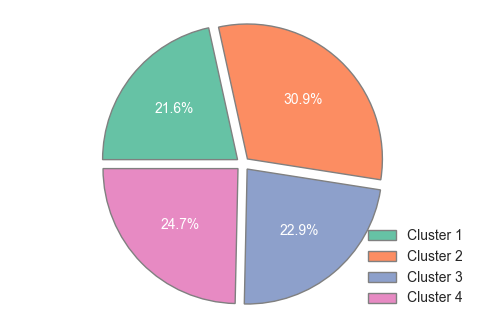

In [40]:
visualize_cluster_distribution(
    kmean_pca.labels_
)

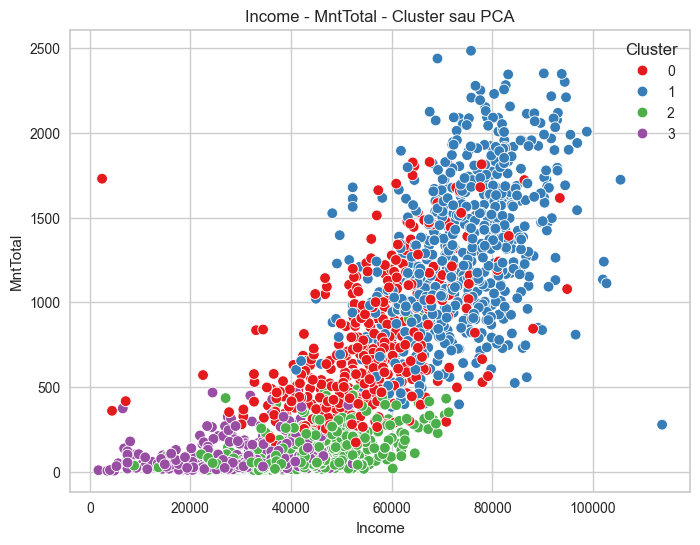

In [41]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=kmean_pca_df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1',
    s=60
)

plt.title('Income - MntTotal - Cluster sau PCA')
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.grid(True)
plt.show()

In [42]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

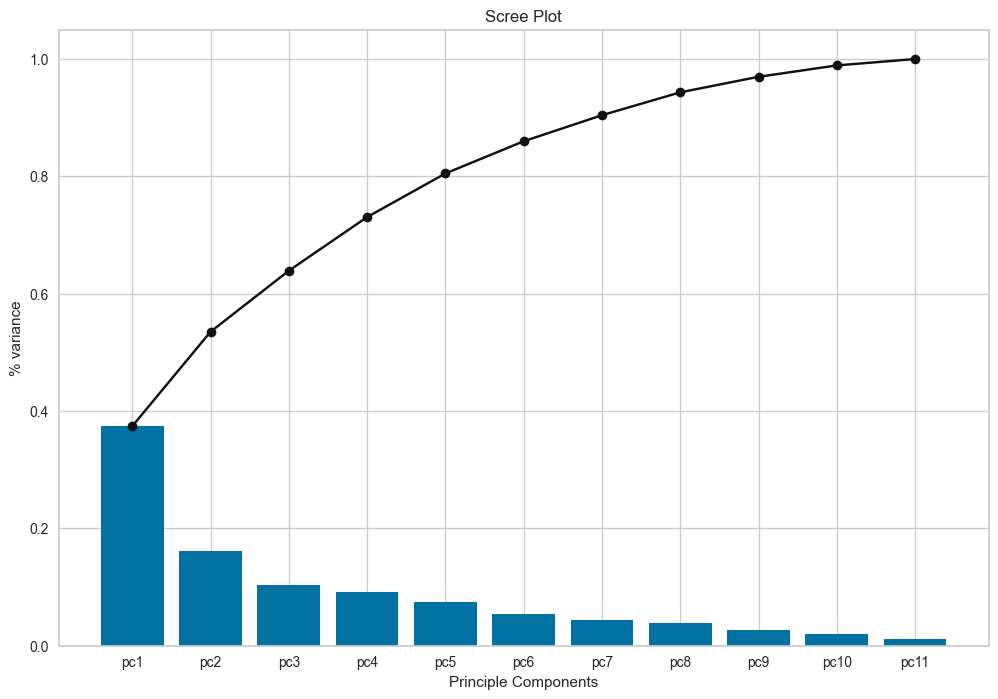

In [43]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [44]:
# biến đổi df sang không gian pca 4 chiều
# TODO
# pca_transformed_4d = 

In [45]:
# model = KMeans(n_init=20, random_state=99)
# visualizer = KElbowVisualizer(model, k=10)
# visualizer.fit(pca_transformed_4d)
# visualizer.show()

In [46]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
# kmean_pca_df = customer_data.copy()
# kmean_pca_df['Cluster'] = kmean.labels_
# kmean_pca_df.head()

In [47]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [48]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [49]:
len(df.columns)

11

In [50]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [51]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [52]:
import pandas as pd

In [53]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


In [54]:
df = df.dropna(subset=['LAT', 'LON']).copy()

print("Kích thước dữ liệu:", df.shape)
print("Số giá trị thiếu LAT:", df['LAT'].isna().sum())
print("Số giá trị thiếu LON:", df['LON'].isna().sum())

Kích thước dữ liệu: (837, 3)
Số giá trị thiếu LAT: 0
Số giá trị thiếu LON: 0


**Biểu diễn giá trị toạ độ trên bản đồ**

In [55]:
import folium, re

c:\Users\mythi\AppData\Local\Programs\Python\Python39\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [56]:

X = df[['LAT', 'LON']].values

m = folium.Map(
    location=[X[:, 0].mean(), X[:, 1].mean()],
    tiles='OpenStreetMap',
    zoom_start=10
)

m

In [57]:
X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='OpenStreetMap', zoom_start=10)

In [58]:
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT, row.LON],
        radius=5,
        popup=re.sub(r'\W+', ' ', str(row.NAME)),
        fill=True
    ).add_to(m)

title = '''
<h3 align="center" style="font-size:30px">
<b>Given Data</b>
</h3>
'''

m.get_root().html.add_child(
    folium.Element(title)
)

m

In [59]:
from sklearn.preprocessing import StandardScaler

X = df[['LAT', 'LON']].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.56623206  0.51813017]
 [ 1.56958054  0.50898854]
 [-1.50667658 -1.08022379]
 [-0.4653362   0.2713985 ]
 [ 0.1542875   0.16197596]]


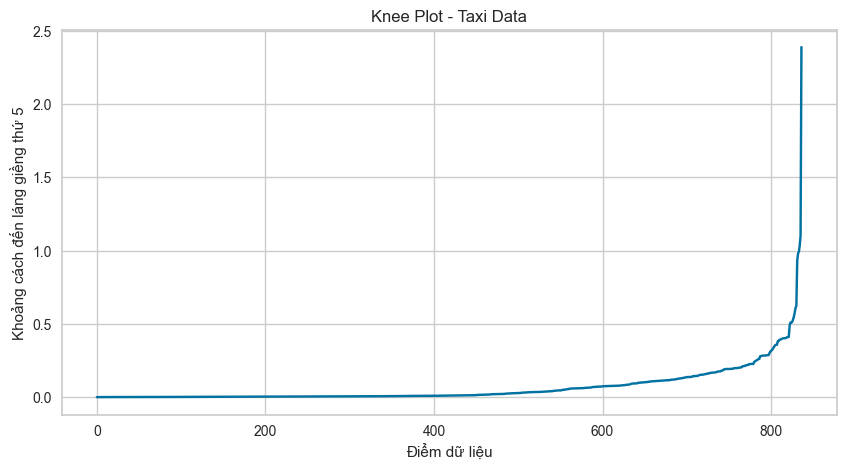

In [60]:
# Knee plot để ước lượng eps
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel('Điểm dữ liệu')
plt.ylabel('Khoảng cách đến láng giềng thứ 5')
plt.title('Knee Plot - Taxi Data')

plt.grid(True)

plt.show()

In [61]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [62]:
# Sử dụng DBSCAN để phân cụm
from sklearn.cluster import DBSCAN

eps = 0.15

dbscan = DBSCAN(
    eps=eps,
    min_samples=5
)

df['Cluster'] = dbscan.fit_predict(X_scaled)

df.head()

,LON,LAT,NAME,Cluster
0,28.17858,-25.73882,11th Street Taxi Rank,0
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank,0
2,27.83239,-26.53722,Adams Road Taxi Rank,1
3,28.12514,-26.26666,Alberton City Mall Taxi Rank,-1
4,28.10144,-26.10567,Alexandra Main Taxi Rank,2


In [63]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
-1      99
 0      31
 1      55
 2      46
 3      38
 4     114
 5      26
 6      17
 7      23
 8      22
 9       8
 10      9
 11     77
 12     36
 13      5
 14      5
 15     10
 16     11
 17      8
 18      5
 19     24
 20      8
 21      6
 22      6
 23     13
 24      9
 25      6
 26      5
 27      9
 28     14
 29     18
 30     10
 31      8
 32      7
 33      6
 34     12
 35     12
 36      8
 37      6
 38      5
Name: count, dtype: int64


In [64]:
n_clusters = len(
    set(df['Cluster']) - {-1}
)

n_noise = sum(
    df['Cluster'] == -1
)

print("Số cụm:", n_clusters)
print("Số điểm nhiễu:", n_noise)

Số cụm: 39
Số điểm nhiễu: 99


In [65]:
unique_clusters = sorted(df['Cluster'].unique())

color_map = {}

color_index = 0

for cluster in unique_clusters:
    if cluster == -1:
        color_map[cluster] = 'black'
    else:
        color_map[cluster] = colors[color_index]
        color_index += 1

df['Color'] = df['Cluster'].map(color_map)

df.head()

,LON,LAT,NAME,Cluster,Color
0,28.17858,-25.73882,11th Street Taxi Rank,0,royalblue
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank,0,royalblue
2,27.83239,-26.53722,Adams Road Taxi Rank,1,maroon
3,28.12514,-26.26666,Alberton City Mall Taxi Rank,-1,black
4,28.10144,-26.10567,Alexandra Main Taxi Rank,2,forestgreen


In [66]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(
        location=[X[:,0].mean(), X[:,1].mean()],
        tiles='OpenStreetMap',
        zoom_start=8.5
    )

    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT, row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column]
        ).add_to(m)

    print(title)
    return m

In [67]:
taxi_map = create_map(
    'Cluster',
    'Color',
    'Taxi Clustering bằng DBSCAN'
)

taxi_map

Taxi Clustering bằng DBSCAN
